# Stage 4 - Model Evaluation
This notebook evaluates trained models on the untouched test set and selects `best_model` with explicit threshold analysis and calibration checks.

In [12]:
from pathlib import Path
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    average_precision_score, brier_score_loss, confusion_matrix,
    precision_recall_curve, roc_curve
)
from sklearn.calibration import calibration_curve, CalibratedClassifierCV

BASE_DIR = Path.cwd().parent
PROCESSED_DIR = BASE_DIR / 'data' / 'processed'
PLOT_DIR = BASE_DIR / 'outputs' / 'plots' / 'stage4'
PLOT_DIR.mkdir(parents=True, exist_ok=True)

def save_plot(name: str):
    path = PLOT_DIR / f'{name}.png'
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches='tight')
    print(f'Saved plot: {path}')


## Load Stage 3 Outputs

In [13]:
with open(PROCESSED_DIR / 'stage3_outputs.pkl', 'rb') as f:
    stage3 = pickle.load(f)
X_test_eng = stage3['X_test_eng']
X_train_eng = stage3['X_train_eng']
y_test = stage3['y_test']
y_train = stage3['y_train']
models = stage3['models']
borrower_type_test = stage3['borrower_type_test']
default_probability_test = stage3['default_probability_test']
cv_summary = stage3['cv_summary']
print('Loaded test shape:', X_test_eng.shape)
print('Models:', list(models.keys()))


Loaded test shape: (2000, 49)
Models: ['lr_l2', 'lr_l1', 'naive_bayes', 'knn', 'decision_tree_overfit', 'decision_tree_tuned', 'random_forest', 'xgboost', 'svm']


## Step 1 - Per-Model Metrics
Compute predictions, probabilities, classification metrics, ROC/PR metrics, Brier score, and confusion matrices.

In [14]:
model_eval = {}
for name, model in models.items():
    if name == 'decision_tree_overfit':
        continue
    y_pred = model.predict(X_test_eng)
    y_prob = model.predict_proba(X_test_eng)[:, 1]
    cm = confusion_matrix(y_test, y_pred)
    model_eval[name] = {
        'y_pred': y_pred,
        'y_prob': y_prob,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_test, y_prob),
        'avg_precision': average_precision_score(y_test, y_prob),
        'brier': brier_score_loss(y_test, y_prob),
        'confusion_matrix': cm,
    }
eval_table = pd.DataFrame({k: {m: v[m] for m in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'avg_precision', 'brier']} for k, v in model_eval.items()}).T
print(eval_table.sort_values('roc_auc', ascending=False))


                     accuracy  precision    recall        f1   roc_auc  \
lr_l1                  0.8430   0.486940  0.870000  0.624402  0.926824   
lr_l2                  0.8415   0.483748  0.843333  0.614824  0.925876   
xgboost                0.8745   0.566757  0.693333  0.623688  0.917931   
random_forest          0.8575   0.516779  0.770000  0.618474  0.914882   
svm                    0.8485   0.496520  0.713333  0.585499  0.892137   
decision_tree_tuned    0.8365   0.471459  0.743333  0.576973  0.881558   
naive_bayes            0.7855   0.396135  0.820000  0.534202  0.881445   
knn                    0.7395   0.352470  0.880000  0.503337  0.871725   

                     avg_precision     brier  
lr_l1                     0.715088  0.107821  
lr_l2                     0.709498  0.106999  
xgboost                   0.690346  0.083705  
random_forest             0.673364  0.094755  
svm                       0.613481  0.103912  
decision_tree_tuned       0.512965  0.135728  
naiv

## Step 2 - Threshold Optimization (Best ROC-AUC Model)
Find max-F1 threshold and recall>=0.80 threshold with highest precision, then compare against default 0.5.

In [15]:
best_model_name = eval_table['roc_auc'].idxmax()
best_model = models[best_model_name]
y_prob_best = model_eval[best_model_name]['y_prob']

threshold_grid = np.arange(0.0, 1.01, 0.01)
threshold_rows = []
for thr in threshold_grid:
    y_pred_thr = (y_prob_best >= thr).astype(int)
    threshold_rows.append({
        'threshold': thr,
        'precision': precision_score(y_test, y_pred_thr, zero_division=0),
        'recall': recall_score(y_test, y_pred_thr, zero_division=0),
        'f1': f1_score(y_test, y_pred_thr, zero_division=0),
    })
threshold_df = pd.DataFrame(threshold_rows)
max_f1_threshold = float(threshold_df.loc[threshold_df['f1'].idxmax(), 'threshold'])
recall_target = 0.80
eligible = threshold_df[threshold_df['recall'] >= recall_target].sort_values(['precision', 'threshold'], ascending=[False, True])
recall80_threshold = float(eligible.iloc[0]['threshold']) if not eligible.empty else 0.5

def metric_at_threshold(threshold: float):
    y_pred = (y_prob_best >= threshold).astype(int)
    return {
        'threshold': threshold,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_test, y_prob_best),
        'avg_precision': average_precision_score(y_test, y_prob_best),
        'brier': brier_score_loss(y_test, y_prob_best),
        'confusion_matrix': confusion_matrix(y_test, y_pred)
    }

threshold_analysis = pd.DataFrame([
    metric_at_threshold(0.5),
    metric_at_threshold(max_f1_threshold),
    metric_at_threshold(recall80_threshold),
])
threshold_analysis.index = ['default_0.5', 'max_f1', 'recall_ge_0.80']
print('Best model:', best_model_name)
print('Max-F1 threshold:', max_f1_threshold)
print('Recall>=0.80 threshold:', recall80_threshold)
print(threshold_analysis[['threshold', 'accuracy', 'precision', 'recall', 'f1']])


Best model: lr_l1
Max-F1 threshold: 0.78
Recall>=0.80 threshold: 0.61
                threshold  accuracy  precision    recall        f1
default_0.5          0.50    0.8430   0.486940  0.870000  0.624402
max_f1               0.78    0.9005   0.671186  0.660000  0.665546
recall_ge_0.80       0.61    0.8630   0.528509  0.803333  0.637566


## Step 3 - Required Plots
Plot ROC and PR curves for all models, confusion matrix per model, and calibration diagnostics for the best model.

Saved plot: d:\College\Sem-4\ML\Course Project\cursor-alt-cred-score\outputs\plots\stage4\stage4_roc_curves_all_models.png


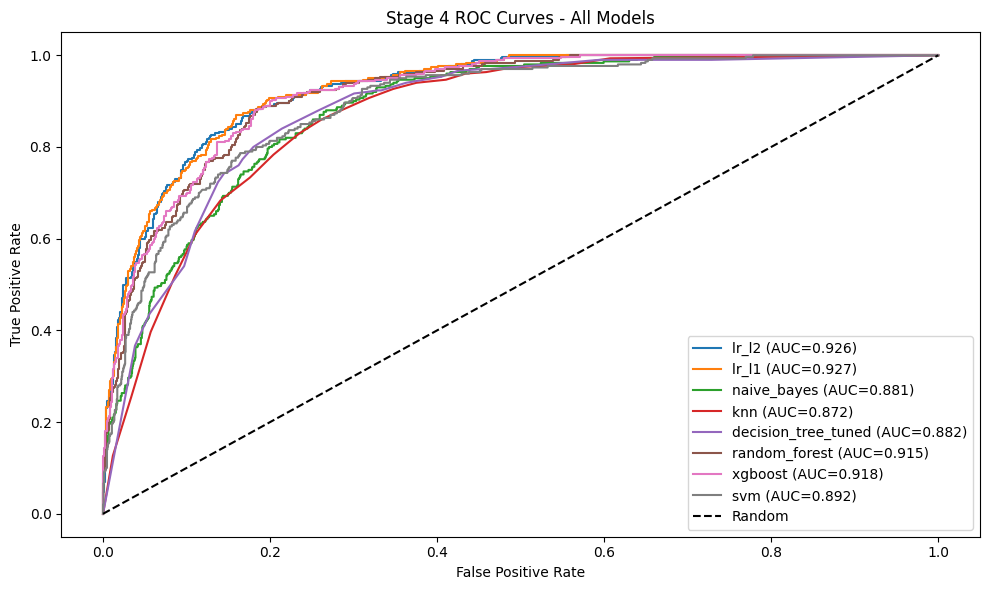

Saved plot: d:\College\Sem-4\ML\Course Project\cursor-alt-cred-score\outputs\plots\stage4\stage4_pr_curves_all_models.png


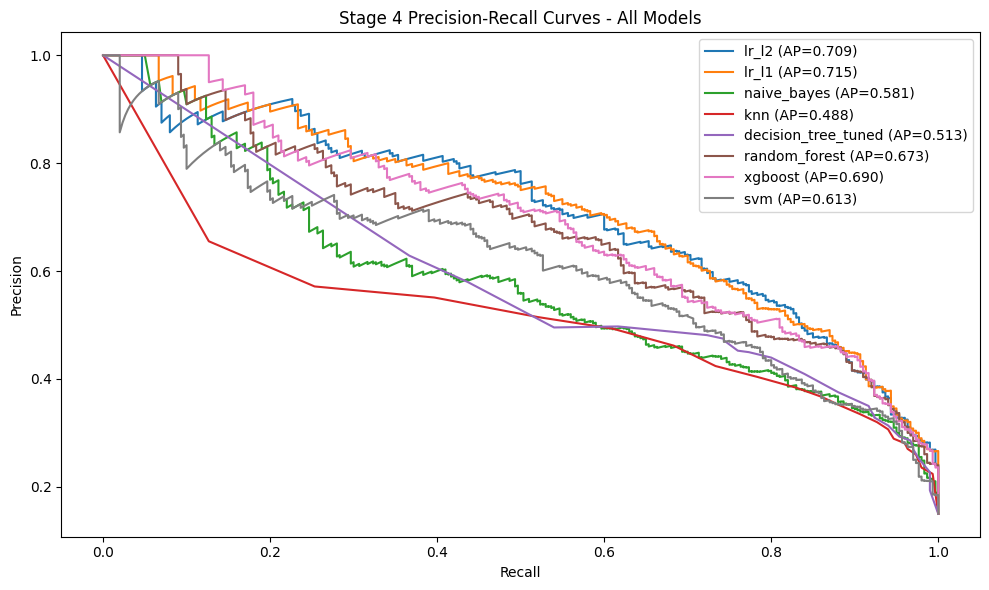

Saved plot: d:\College\Sem-4\ML\Course Project\cursor-alt-cred-score\outputs\plots\stage4\stage4_confusion_matrix_lr_l2.png


C:\Users\shrey\AppData\Local\Temp\ipykernel_22960\3774651510.py:30: UserWarning: Legend does not support handles for QuadMesh instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()
C:\Users\shrey\AppData\Local\Temp\ipykernel_22960\3774651510.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


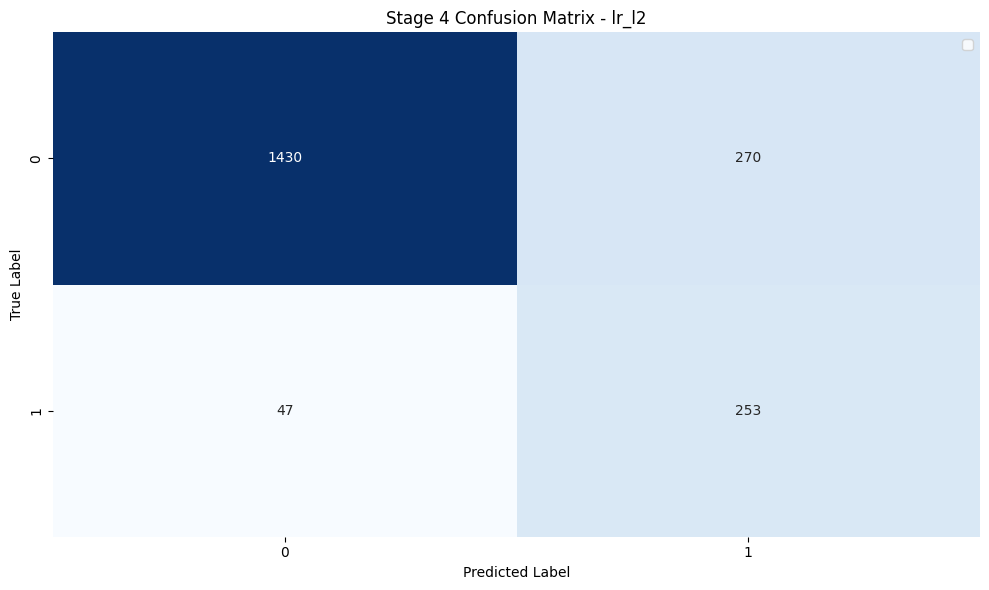

C:\Users\shrey\AppData\Local\Temp\ipykernel_22960\3774651510.py:30: UserWarning: Legend does not support handles for QuadMesh instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()
C:\Users\shrey\AppData\Local\Temp\ipykernel_22960\3774651510.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Saved plot: d:\College\Sem-4\ML\Course Project\cursor-alt-cred-score\outputs\plots\stage4\stage4_confusion_matrix_lr_l1.png


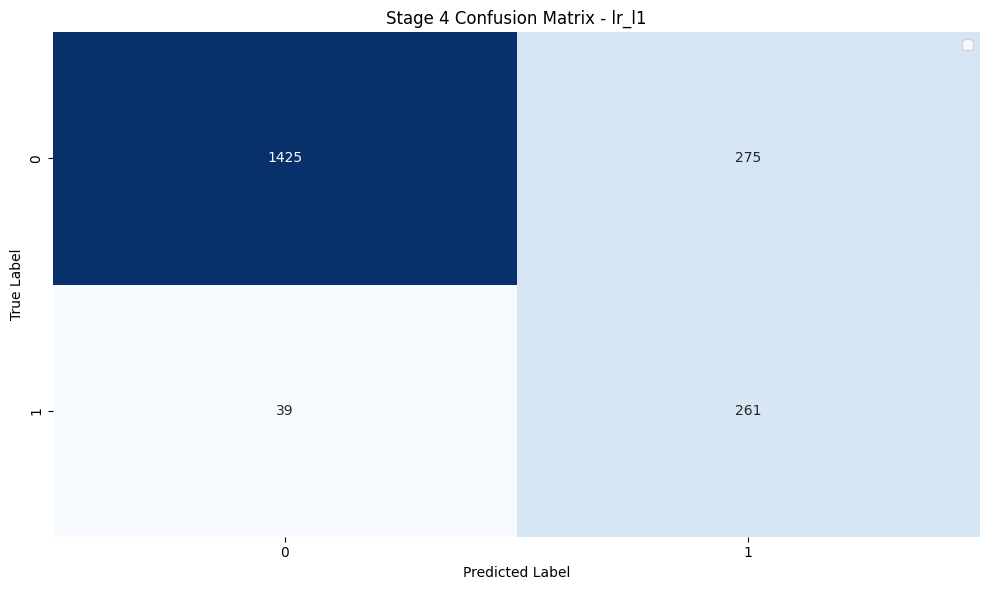

C:\Users\shrey\AppData\Local\Temp\ipykernel_22960\3774651510.py:30: UserWarning: Legend does not support handles for QuadMesh instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()
C:\Users\shrey\AppData\Local\Temp\ipykernel_22960\3774651510.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Saved plot: d:\College\Sem-4\ML\Course Project\cursor-alt-cred-score\outputs\plots\stage4\stage4_confusion_matrix_naive_bayes.png


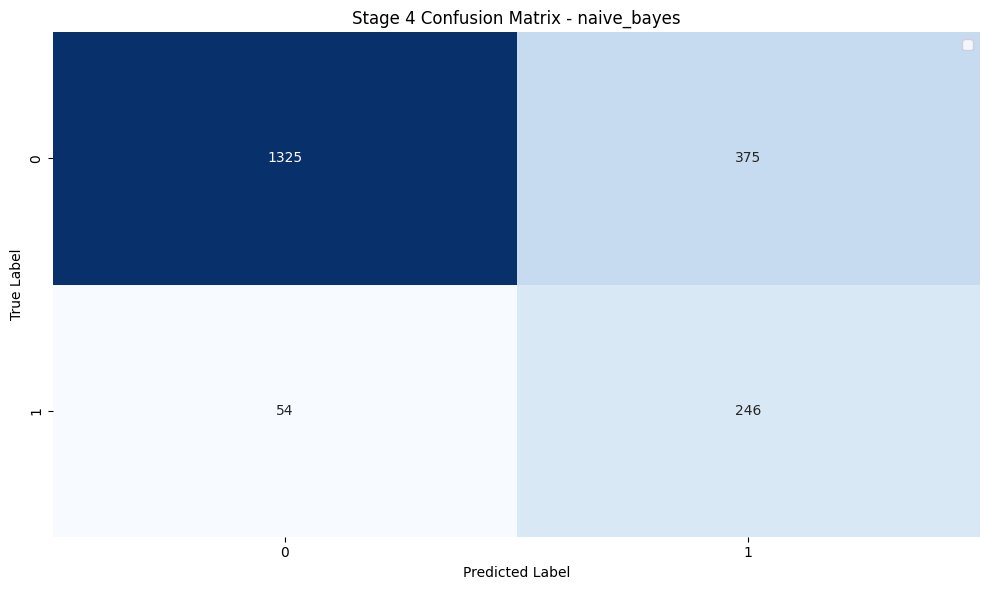

C:\Users\shrey\AppData\Local\Temp\ipykernel_22960\3774651510.py:30: UserWarning: Legend does not support handles for QuadMesh instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()
C:\Users\shrey\AppData\Local\Temp\ipykernel_22960\3774651510.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Saved plot: d:\College\Sem-4\ML\Course Project\cursor-alt-cred-score\outputs\plots\stage4\stage4_confusion_matrix_knn.png


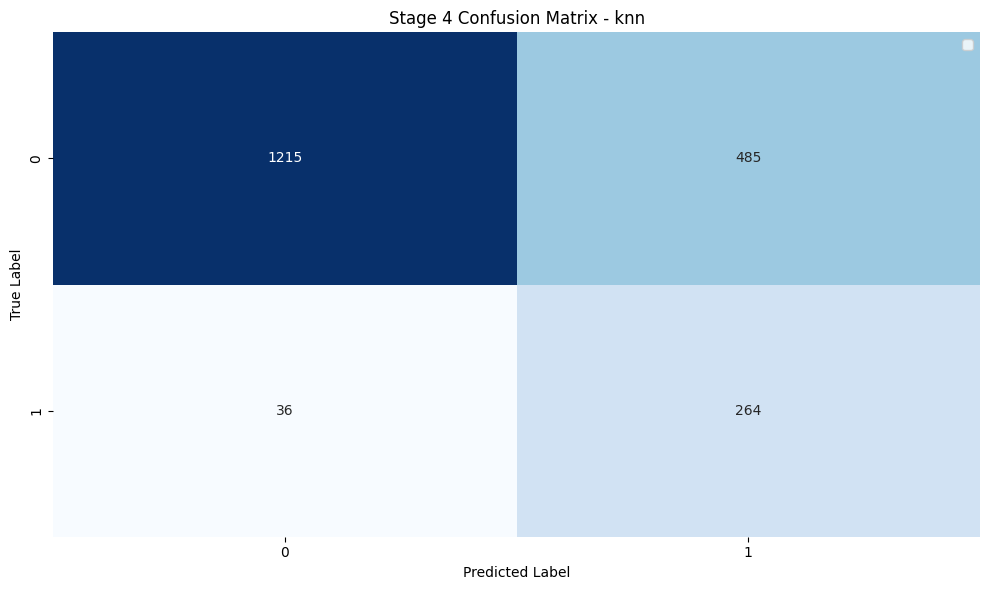

C:\Users\shrey\AppData\Local\Temp\ipykernel_22960\3774651510.py:30: UserWarning: Legend does not support handles for QuadMesh instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()
C:\Users\shrey\AppData\Local\Temp\ipykernel_22960\3774651510.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Saved plot: d:\College\Sem-4\ML\Course Project\cursor-alt-cred-score\outputs\plots\stage4\stage4_confusion_matrix_decision_tree_tuned.png


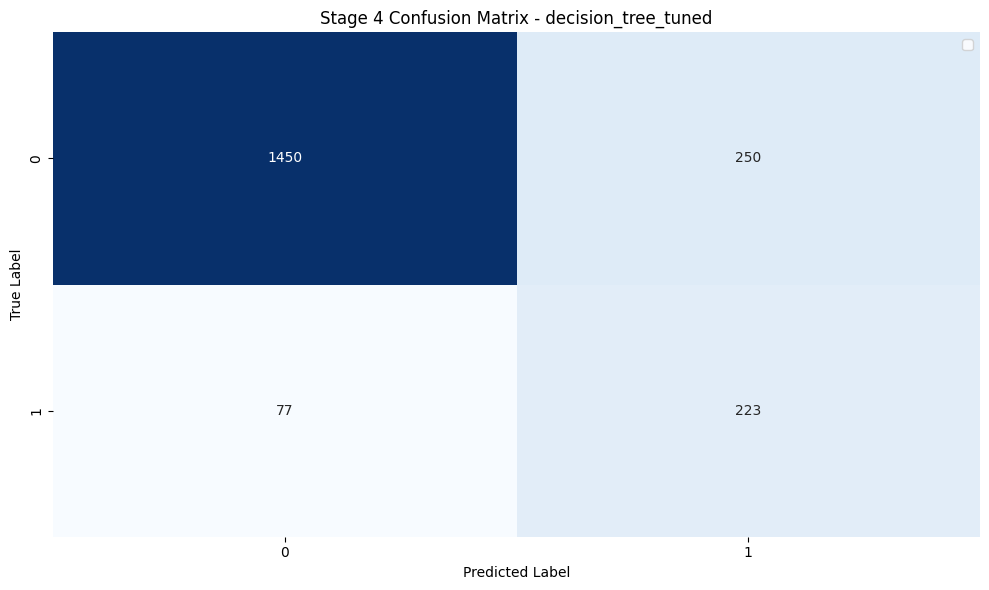

C:\Users\shrey\AppData\Local\Temp\ipykernel_22960\3774651510.py:30: UserWarning: Legend does not support handles for QuadMesh instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()
C:\Users\shrey\AppData\Local\Temp\ipykernel_22960\3774651510.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Saved plot: d:\College\Sem-4\ML\Course Project\cursor-alt-cred-score\outputs\plots\stage4\stage4_confusion_matrix_random_forest.png


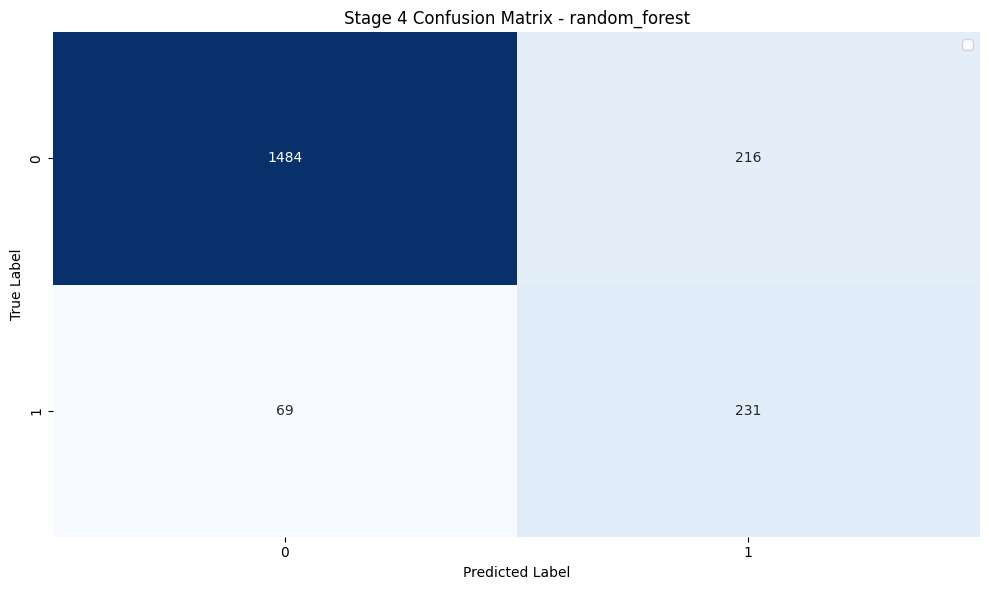

C:\Users\shrey\AppData\Local\Temp\ipykernel_22960\3774651510.py:30: UserWarning: Legend does not support handles for QuadMesh instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()
C:\Users\shrey\AppData\Local\Temp\ipykernel_22960\3774651510.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Saved plot: d:\College\Sem-4\ML\Course Project\cursor-alt-cred-score\outputs\plots\stage4\stage4_confusion_matrix_xgboost.png


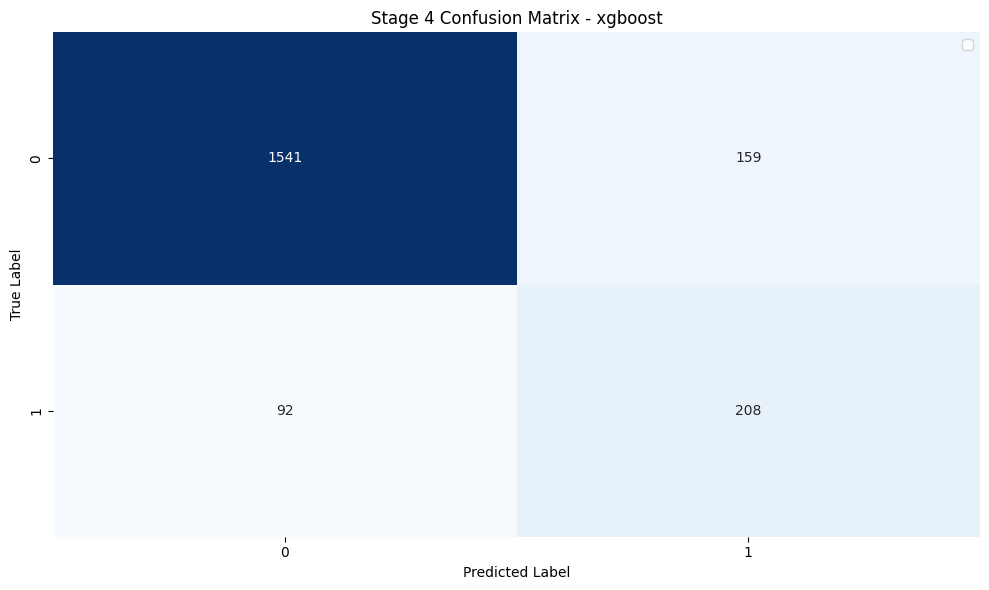

C:\Users\shrey\AppData\Local\Temp\ipykernel_22960\3774651510.py:30: UserWarning: Legend does not support handles for QuadMesh instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()
C:\Users\shrey\AppData\Local\Temp\ipykernel_22960\3774651510.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Saved plot: d:\College\Sem-4\ML\Course Project\cursor-alt-cred-score\outputs\plots\stage4\stage4_confusion_matrix_svm.png


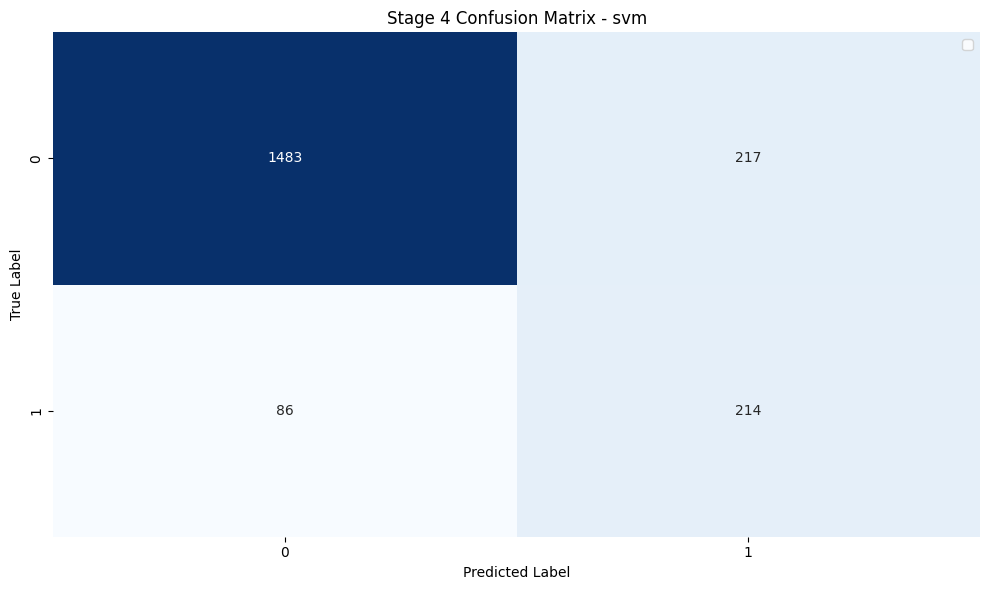

Saved plot: d:\College\Sem-4\ML\Course Project\cursor-alt-cred-score\outputs\plots\stage4\stage4_reliability_diagram_best_model.png


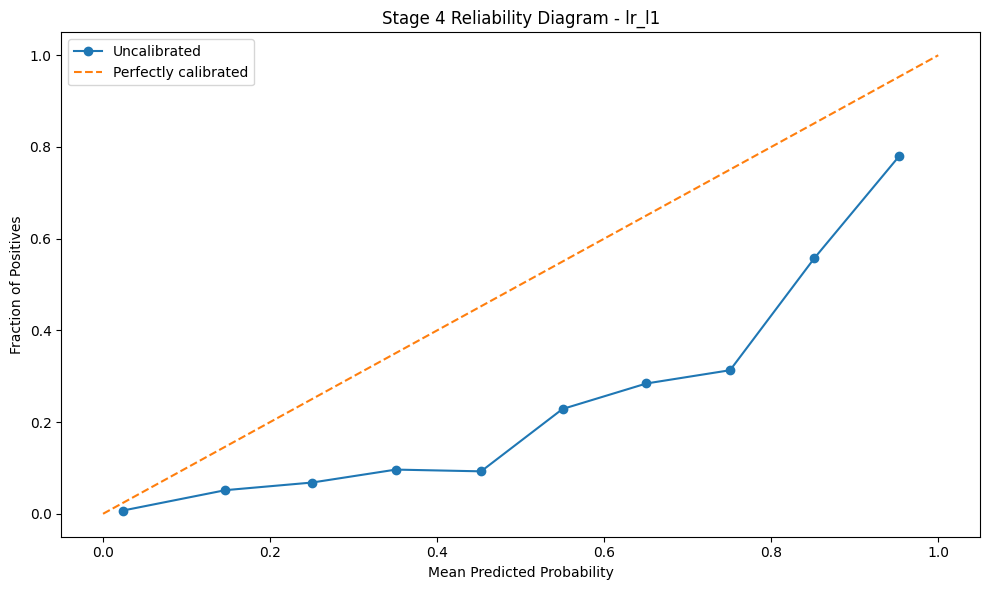

d:\College\Sem-4\ML\Course Project\cursor-alt-cred-score\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\College\Sem-4\ML\Course Project\cursor-alt-cred-score\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
d:\College\Sem-4\ML\Course Project\cursor-alt-cred-score\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_rat

Brier uncalibrated: 0.10782076622606357
Brier calibrated (isotonic): 0.0739343729681667


In [16]:
plt.figure(figsize=(10, 6))
for name, info in model_eval.items():
    fpr, tpr, _ = roc_curve(y_test, info['y_prob'])
    plt.plot(fpr, tpr, label=f"{name} (AUC={info['roc_auc']:.3f})")
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.title('Stage 4 ROC Curves - All Models')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
save_plot('stage4_roc_curves_all_models')
plt.show()

plt.figure(figsize=(10, 6))
for name, info in model_eval.items():
    precision, recall, _ = precision_recall_curve(y_test, info['y_prob'])
    plt.plot(recall, precision, label=f"{name} (AP={info['avg_precision']:.3f})")
plt.title('Stage 4 Precision-Recall Curves - All Models')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
save_plot('stage4_pr_curves_all_models')
plt.show()

for name, info in model_eval.items():
    plt.figure(figsize=(10, 6))
    sns.heatmap(info['confusion_matrix'], annot=True, fmt='d', cmap='Blues', cbar=False, label='Count')
    plt.title(f'Stage 4 Confusion Matrix - {name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.legend()
    save_plot(f'stage4_confusion_matrix_{name}')
    plt.show()

frac_pos, mean_pred = calibration_curve(y_test, y_prob_best, n_bins=10)
plt.figure(figsize=(10, 6))
plt.plot(mean_pred, frac_pos, marker='o', label='Uncalibrated')
plt.plot([0, 1], [0, 1], linestyle='--', label='Perfectly calibrated')
plt.title(f'Stage 4 Reliability Diagram - {best_model_name}')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.legend()
save_plot('stage4_reliability_diagram_best_model')
plt.show()

calibrator = CalibratedClassifierCV(best_model, method='isotonic', cv=5)
calibrator.fit(X_train_eng, y_train)
y_prob_cal = calibrator.predict_proba(X_test_eng)[:, 1]
brier_uncal = brier_score_loss(y_test, y_prob_best)
brier_cal = brier_score_loss(y_test, y_prob_cal)
print('Brier uncalibrated:', brier_uncal)
print('Brier calibrated (isotonic):', brier_cal)


## Step 4 - Comparative Summary Table
Create a consolidated table with test metrics and CV ROC-AUC mean/std for all models.

In [17]:
cv_lookup = cv_summary.set_index('model')[['roc_auc_mean', 'roc_auc_std']].rename(columns={'roc_auc_mean': 'cv_roc_auc_mean', 'roc_auc_std': 'cv_roc_auc_std'})
name_map = {
    'lr_l2': 'LR_L2', 'lr_l1': 'LR_L1', 'naive_bayes': 'NaiveBayes', 'knn': 'KNN',
    'decision_tree_tuned': 'DecisionTree_Tuned', 'random_forest': 'RandomForest', 'xgboost': 'XGBoost', 'svm': 'SVM'
}
summary_rows = []
for key, info in model_eval.items():
    cv_key = name_map[key]
    summary_rows.append({
        'model': key,
        'test_accuracy': info['accuracy'],
        'test_precision': info['precision'],
        'test_recall': info['recall'],
        'test_f1': info['f1'],
        'test_roc_auc': info['roc_auc'],
        'test_avg_precision': info['avg_precision'],
        'brier_score': info['brier'],
        'cv_roc_auc_mean': cv_lookup.loc[cv_key, 'cv_roc_auc_mean'],
        'cv_roc_auc_std': cv_lookup.loc[cv_key, 'cv_roc_auc_std'],
    })
comparative_table = pd.DataFrame(summary_rows).sort_values('test_roc_auc', ascending=False).reset_index(drop=True)
print(comparative_table)


                 model  test_accuracy  test_precision  test_recall   test_f1  \
0                lr_l1         0.8430        0.486940     0.870000  0.624402   
1                lr_l2         0.8415        0.483748     0.843333  0.614824   
2              xgboost         0.8745        0.566757     0.693333  0.623688   
3        random_forest         0.8575        0.516779     0.770000  0.618474   
4                  svm         0.8485        0.496520     0.713333  0.585499   
5  decision_tree_tuned         0.8365        0.471459     0.743333  0.576973   
6          naive_bayes         0.7855        0.396135     0.820000  0.534202   
7                  knn         0.7395        0.352470     0.880000  0.503337   

   test_roc_auc  test_avg_precision  brier_score  cv_roc_auc_mean  \
0      0.926824            0.715088     0.107821         0.926977   
1      0.925876            0.709498     0.106999         0.926705   
2      0.917931            0.690346     0.083705         0.923678   
3  

## Step 5 - Segment-wise Evaluation
Evaluate the best model by borrower segment and flag recall below 0.60.

In [18]:
best_threshold = max_f1_threshold
y_pred_best_thr = (y_prob_best >= best_threshold).astype(int)
segment_rows = []
for seg in sorted(borrower_type_test.unique()):
    mask = borrower_type_test == seg
    y_true_seg = y_test[mask]
    y_pred_seg = y_pred_best_thr[mask]
    y_prob_seg = y_prob_best[mask]
    segment_rows.append({
        'borrower_type': seg,
        'precision': precision_score(y_true_seg, y_pred_seg, zero_division=0),
        'recall': recall_score(y_true_seg, y_pred_seg, zero_division=0),
        'f1': f1_score(y_true_seg, y_pred_seg, zero_division=0),
        'roc_auc': roc_auc_score(y_true_seg, y_prob_seg) if y_true_seg.nunique() > 1 else np.nan,
    })
segment_table = pd.DataFrame(segment_rows)
print(segment_table)
for _, r in segment_table.iterrows():
    if r['recall'] < 0.60:
        print(f"FLAG: Recall below 0.60 for segment {r['borrower_type']}: {r['recall']:.3f}")


  borrower_type  precision    recall        f1   roc_auc
0           gig   0.681319  0.563636  0.616915  0.937759
1       migrant   0.567568  0.656250  0.608696  0.935215
2         rural   0.688623  0.727848  0.707692  0.886840
FLAG: Recall below 0.60 for segment gig: 0.564


## Step 6 - Select Final Best Model
Select best model using ROC-AUC primary criterion, average precision tiebreaker, and Brier score secondary consideration.

In [19]:
best_candidates = comparative_table.sort_values(['test_roc_auc', 'test_avg_precision', 'brier_score'], ascending=[False, False, True])
final_best_name = best_candidates.iloc[0]['model']
best_model = models[final_best_name]
print('Final selected best_model:', final_best_name)
print(best_candidates.head(3))


Final selected best_model: lr_l1
     model  test_accuracy  test_precision  test_recall   test_f1  \
0    lr_l1         0.8430        0.486940     0.870000  0.624402   
1    lr_l2         0.8415        0.483748     0.843333  0.614824   
2  xgboost         0.8745        0.566757     0.693333  0.623688   

   test_roc_auc  test_avg_precision  brier_score  cv_roc_auc_mean  \
0      0.926824            0.715088     0.107821         0.926977   
1      0.925876            0.709498     0.106999         0.926705   
2      0.917931            0.690346     0.083705         0.923678   

   cv_roc_auc_std  
0        0.002810  
1        0.003956  
2        0.002925  


## Save Stage 4 Outputs

In [20]:
stage4_output = {
    **stage3,
    'model_eval': model_eval,
    'comparative_table': comparative_table,
    'threshold_analysis': threshold_analysis,
    'segment_table': segment_table,
    'best_model_name': final_best_name,
    'best_model': best_model,
    'max_f1_threshold': max_f1_threshold,
    'recall80_threshold': recall80_threshold,
    'calibrated_brier': brier_cal,
    'uncalibrated_brier': brier_uncal,
}
out_path = PROCESSED_DIR / 'stage4_outputs.pkl'
with open(out_path, 'wb') as f:
    pickle.dump(stage4_output, f)
print('Saved:', out_path)


Saved: d:\College\Sem-4\ML\Course Project\cursor-alt-cred-score\data\processed\stage4_outputs.pkl


## Stage 4 Summary

In [21]:
print('=' * 70)
print('STAGE 4 SUMMARY')
print('- Evaluated all required models (excluding DT-overfit from main comparison).')
print(f"- Selected best model: {final_best_name}")
print(f"- Max-F1 threshold: {max_f1_threshold:.2f}")
print(f"- Recall>=0.80 threshold: {recall80_threshold:.2f}")
print(f"- Comparative table shape: {comparative_table.shape}")
print(f"- Segment table shape: {segment_table.shape}")
print(f"- Saved outputs to: {out_path}")
print('=' * 70)


STAGE 4 SUMMARY
- Evaluated all required models (excluding DT-overfit from main comparison).
- Selected best model: lr_l1
- Max-F1 threshold: 0.78
- Recall>=0.80 threshold: 0.61
- Comparative table shape: (8, 10)
- Segment table shape: (3, 5)
- Saved outputs to: d:\College\Sem-4\ML\Course Project\cursor-alt-cred-score\data\processed\stage4_outputs.pkl


In [22]:
inference_s4 = {
    'thresholds': {
        'default': 0.5,
        'max_f1': float(max_f1_threshold),
        'conservative': float(recall80_threshold),
    }
}
with open(PROCESSED_DIR / 'inference_artifacts_stage4.pkl', 'wb') as f:
    pickle.dump(inference_s4, f)
